__Лабораторная работа №18__

Используя механизм получения данных с рынков, описанный в документации,  
примените модель “Плавающего окна” для прогноза акций любой компании

(например: цена закрытия акций IBM, используя механизм stooq)


---

In [1]:
# !pip install pandas_datareader
# !pip install tsfresh

## загружаем данные

In [2]:
# from tqdm.auto import tqdm
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
import pandas_datareader.data as web

In [3]:
data = web.DataReader("IBM", 'stooq').rename(columns={'Close':'Value'})[['Value']].sort_index()
display( data.info() )
display( data.head() )

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1256 entries, 2018-08-09 to 2023-08-07
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Value   1256 non-null   float64
dtypes: float64(1)
memory usage: 19.6 KB


None

,Value
Date,
2018-08-09,117.559
2018-08-10,117.315
2018-08-13,115.910
2018-08-14,116.428
2018-08-15,116.867


In [4]:
display(( data.index.min(), data.index.max() ))

(Timestamp('2018-08-09 00:00:00'), Timestamp('2023-08-07 00:00:00'))

In [5]:
year_split = '2022-01-01'
data_train, data_test = data[:year_split], data[year_split:]
display( ( data_train.shape, data_test.shape ) )

((856, 1), (400, 1))

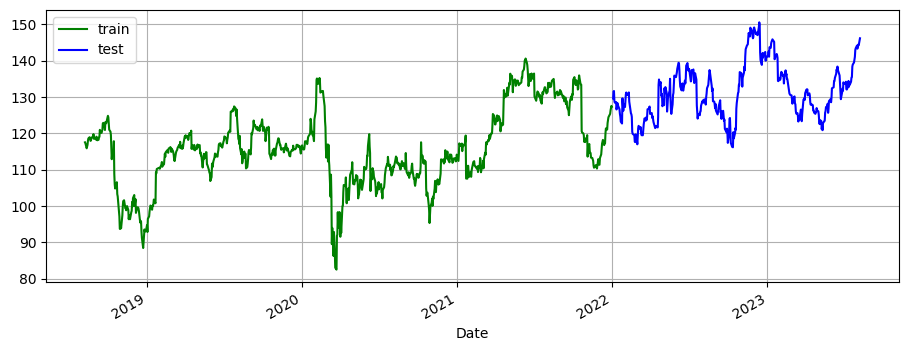

In [6]:
fig,ax = plt.subplots(figsize=(11,4))
data_train['Value'].plot(ax=ax,label='train',c='g')
data_test['Value'].plot(ax=ax,label='test',c='b')
plt.legend()
plt.grid()

## собираем учебный датасет

In [7]:
import tsfresh
from tsfresh.utilities import dataframe_functions as F

In [8]:
# для каждого значения формируем  историю предыдущих значений
data_train_roll = data_train.copy().reset_index()
data_train_roll['symbols'] = 'IBM'

window_size = (3,7) # размер окна, по которому будем строить прогноз

data_train_roll = F.roll_time_series(
        data_train_roll,
        column_id='symbols', 
        column_sort='Date',
        # rolling_direction=1,
        min_timeshift=window_size[0],
        max_timeshift=window_size[1], 
        # show_warnings=False,
        disable_progressbar=True,
        n_jobs=4,
    ).drop(columns=['symbols'])

# метка группы
data_train_roll['id'] = pd.to_datetime(data_train_roll['id'].str[1])
display( data_train_roll.shape )
display( data_train_roll.head())

/opt/venv/nb_3.11/lib/python3.11/site-packages/tsfresh/utilities/dataframe_functions.py:520: UserWarning: Your time stamps are not uniformly sampled, which makes rolling nonsensical in some domains.
  warnings.warn(


(6814, 3)

,Date,Value,id
688,2018-08-09,117.559,2018-08-14
689,2018-08-10,117.315,2018-08-14
690,2018-08-13,115.910,2018-08-14
691,2018-08-14,116.428,2018-08-14
692,2018-08-09,117.559,2018-08-15


In [9]:
# # проверяем результат

# # выбираем временную метку
# d = pd.to_datetime('2019-07-10')

# # история значений для временной метки включая текущую (последняя)
# display( data_train_roll[ data_train_roll['id']==d ])

In [10]:
# # предыдущее от выбранной метки значение в окне
# display(data_train.shift(1).loc[[d]]) 

In [11]:
# # значение для временной метки
# display(data_train.loc[[d]]) 

In [12]:
# # следующее за выбранной меткой значение за окном 
# display(data_train.shift(-1).loc[[d]]) 

In [13]:
# assert ( data_train_roll[data_train_roll['id']==d]['Value'].values[-1] == data_train.loc[d].values[0] )

---

In [14]:
# желаемые значения прогноза для последовательностей
target_train = data_train.shift(-1)['Value'].dropna()
display(target_train.shape)
display(target_train)

(855,)

Date
2018-08-09    117.315
2018-08-10    115.910
2018-08-13    116.428
2018-08-14    116.867
2018-08-15    118.018
               ...   
2021-12-23    125.396
2021-12-27    126.362
2021-12-28    127.045
2021-12-29    127.582
2021-12-30    127.348
Name: Value, Length: 855, dtype: float64

---

In [15]:
# display( (data_train_roll['id'].min(),data_train_roll['id'].max() ) )
# display( (target_train.index.min(),target_train.index.max()) ) 

In [16]:
# выкидываем вектор-фичерсы без таргета
display( ( data_train_roll.shape, target_train.shape ) )
idx = set(data_train_roll['id']) & set(target_train.index)
data_train_roll = data_train_roll[ data_train_roll['id'].isin(idx) ].reset_index(drop=True).sort_values(by='id')
target_train = target_train[ target_train.index.isin(idx) ].sort_index()
display( ( data_train_roll.shape, target_train.shape ) )

((6814, 3), (855,))

((6806, 3), (852,))

In [17]:
# display( (min(idx),max(idx), ) )
# display( (data_train_roll['id'].min(),data_train_roll['id'].max() ) )
# display( (target_train.index.min(),target_train.index.max() ) )

---

In [18]:
%%time

# генерируем фичерсы для последовательностей

from tsfresh import extract_relevant_features

x_train = extract_relevant_features(
    data_train_roll, target_train,
    column_id='id',
    column_sort='Date',
    show_warnings=False,
    disable_progressbar=True,
    n_jobs=4,
)

display( x_train.shape )
display( x_train.head() )

(852, 140)

,"Value__cwt_coefficients__coeff_7__w_2__widths_(2, 5, 10, 20)","Value__cwt_coefficients__coeff_7__w_5__widths_(2, 5, 10, 20)","Value__cwt_coefficients__coeff_6__w_2__widths_(2, 5, 10, 20)","Value__cwt_coefficients__coeff_7__w_10__widths_(2, 5, 10, 20)","Value__cwt_coefficients__coeff_7__w_20__widths_(2, 5, 10, 20)","Value__cwt_coefficients__coeff_6__w_5__widths_(2, 5, 10, 20)","Value__cwt_coefficients__coeff_6__w_10__widths_(2, 5, 10, 20)","Value__cwt_coefficients__coeff_6__w_20__widths_(2, 5, 10, 20)",Value__minimum,Value__quantile__q_0.1,...,"Value__fft_coefficient__attr_""real""__coeff_1",Value__partial_autocorrelation__lag_2,Value__has_duplicate,Value__percentage_of_reoccurring_values_to_all_values,Value__ratio_value_number_to_time_series_length,Value__percentage_of_reoccurring_datapoints_to_all_datapoints,"Value__change_quantiles__f_agg_""mean""__isabs_False__qh_0.6__ql_0.0",Value__lempel_ziv_complexity__bins_100,Value__has_duplicate_max,"Value__change_quantiles__f_agg_""mean""__isabs_True__qh_0.8__ql_0.4"
2018-08-14,102.112933,174.649853,125.465236,148.477088,110.106449,213.633130,179.175733,132.379501,115.91,116.0654,...,1.649000,-0.312943,0.0,0.0,1.0,0.0,0.518000,1.0,0.0,0.000
2018-08-15,102.112933,174.649853,125.465236,148.477088,110.106449,213.633130,179.175733,132.379501,115.91,116.1172,...,1.959827,-0.312943,0.0,0.0,1.0,0.0,0.478500,1.0,0.0,0.000
2018-08-16,102.112933,174.649853,125.465236,148.477088,110.106449,213.633130,179.175733,132.379501,115.91,116.1690,...,2.409000,-0.651770,0.0,0.0,1.0,0.0,-0.149333,1.0,0.0,0.244
2018-08-17,102.112933,174.649853,91.680074,148.477088,110.106449,148.378612,122.363087,89.960204,115.91,116.2208,...,2.419151,-0.676445,0.0,0.0,1.0,0.0,-0.149333,1.0,0.0,0.244
2018-08-20,105.996380,178.633035,129.541117,151.688649,112.423773,217.833309,182.435933,134.717709,115.91,116.2726,...,1.988834,-0.622685,0.0,0.0,1.0,0.0,-0.173000,1.0,0.0,0.244


CPU times: user 2.31 s, sys: 187 ms, total: 2.5 s
Wall time: 8.71 s


In [19]:
del data_train_roll

In [20]:
feature_settings =  tsfresh.feature_extraction.settings.from_columns(x_train)
feature_order = x_train.columns

## собираем тестовый датасет

In [21]:
# для каждого значения формируем  историю предыдущих значений
data_test_roll = data_test.copy().reset_index()
data_test_roll['symbols'] = 'IBM'

#window_size = (3,7) # размер окна, по которому будем строить прогноз

data_test_roll = F.roll_time_series(
        data_test_roll,
        column_id='symbols', 
        column_sort='Date',
        # rolling_direction=1,
        min_timeshift=window_size[0],
        max_timeshift=window_size[1], 
        # show_warnings=False,
        disable_progressbar=True,
        n_jobs=4,
    ).drop(columns=['symbols'])

# метка группы
data_test_roll['id'] = pd.to_datetime(data_test_roll['id'].str[1])
display( data_test_roll.shape )


# желаемые значения прогноза для последовательностей
target_test = data_test.shift(-1)['Value'].dropna()
y_test = target_test.values[:,np.newaxis]
display(y_test.shape)


# выкидываем вектор-фичерсы без таргета
idx = set(data_test_roll['id']) & set(target_test.index)
data_test_roll = data_test_roll[ data_test_roll['id'].isin(idx) ].reset_index(drop=True).sort_values(by='id')
target_test = target_test[ target_test.index.isin(idx) ].sort_index()
display( ( data_test_roll.shape, target_test.shape ) )


from tsfresh.feature_extraction import extract_features

x_test = extract_features(
    data_test_roll, 
    default_fc_parameters=feature_settings['Value'],
    column_id='id', 
    column_sort='Date',
    column_value='Value',
    disable_progressbar=True,
    impute_function=F.impute, 
    show_warnings=False,
    n_jobs=4,
)[feature_order]

display( x_test.shape )

/opt/venv/nb_3.11/lib/python3.11/site-packages/tsfresh/utilities/dataframe_functions.py:520: UserWarning: Your time stamps are not uniformly sampled, which makes rolling nonsensical in some domains.
  warnings.warn(


(3166, 3)

(399, 1)

((3158, 3), (396,))

(396, 140)

## строим и обучаем предиктор

In [22]:
from sklearn.linear_model import LinearRegression

model = LinearRegression().fit(x_train, target_train)

## тестируем

In [23]:
from sklearn.metrics import mean_squared_error

### тест на учебном наборе

In [24]:
y_train_pred = model.predict(x_train) # считаем выход для тестовых примеров

# преобразуем обратно во временной ряд
y_train_pred = pd.Series( y_train_pred.flatten(), index=x_train.index)

In [25]:
# MSQE конечного результата после обратного масштабирования 
display( mean_squared_error( y_true=target_train, y_pred=y_train_pred, ) )

3.21738796153049

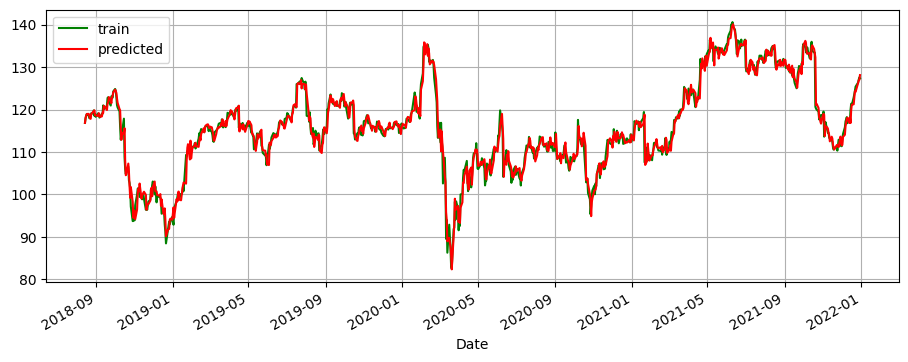

In [26]:
fig,ax = plt.subplots(figsize=(11,4))
target_train.plot(ax=ax,label='train',c='g')
y_train_pred.plot(ax=ax,label='predicted',c='r')
plt.legend()
plt.grid()

### тест на тестовом наборе

In [27]:
display( window_size[1] )

7

In [28]:
y_test_pred = model.predict(x_test) # считаем выход для тестовых примеров

# преобразуем обратно во временной ряд
y_test_pred = pd.Series( y_test_pred.flatten(), index=x_test.index)

In [29]:
# выкидываем предикт с недостаточной историей
y_test_pred = y_test_pred[ window_size[1]: ]
y_test      = y_test[ window_size[1]: ]

In [30]:
# MSQE конечного результата после обратного масштабирования 
display( mean_squared_error( y_true=target_test[ window_size[1]: ], y_pred=y_test_pred, ) )

4.553283519883827

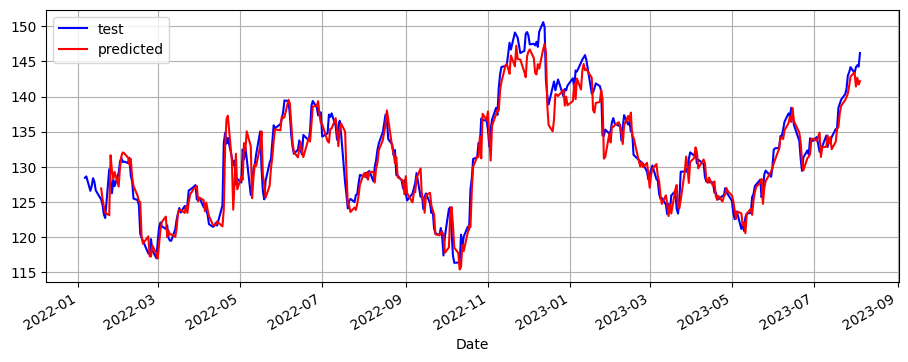

In [31]:
fig,ax = plt.subplots(figsize=(11,4))
target_test.plot(ax=ax,label='test',c='b')
y_test_pred.plot(ax=ax,label='predicted',c='r')
plt.legend()
plt.grid()